# Diffusion coefficients from financial data

In financial modeling, asset prices are often represented using continuous-time stochastic processes to capture the randomness observed in markets. A widely used model is the geometric Brownian motion (GBM), which serves as the foundation for the [Black-Scholes](https://fr.wikipedia.org/wiki/Mod%C3%A8le_Black-Scholes) option pricing framework. In such models, the diffusion coefficient plays a central role: it quantifies the magnitude of randomness or volatility in asset returns. Mathematically, the diffusion coefficient appears as the multiplier of the Brownian motion term in a stochastic differential equation (SDE) :

$$ 
    d x_t = b \,d t +\sqrt{2D} \, dW_t
$$

where $(W_t)_{t\geq 0}$ is a Brownian motion, $D$ the diffusion coefficient (related to volatility $\sigma$, see below), $b$ a bias, and $S_t=e^{x_t}$ is the asset price.

This exercise aims to introduce the concept of diffusion coefficients, explore their interpretation in financial contexts through the example of the [S&P](https://fr.wikipedia.org/wiki/S%26P_500)  and [Nikkei 225](https://fr.wikipedia.org/wiki/Nikkei_225) indices, and guide you through examples involving their computation and estimation.

The usual Black-Scholes-Merton SDE for the asset price is
$$
    \frac{dS_t}{S_t} = \mu \, dt + \sigma \, dW_t
$$
where $(W_t)_{t\geq 0}$ is a Brownian motion. If we define $x_t := \ln S_t$, then using Îto's formula we have that
$$
    d x_t = \left(\mu - \frac{\sigma^2}{2} \right) \, dt + \sigma \, dW_t,
$$
so that
$$
    D = \frac{\sigma^2}{2}, \qquad b = \mu - D.
$$

![Trading.png](Trading.png)

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import pandas as pd

### Reading the data
Here's a script to read the two data files using `pd.read_csv` of the pandas library, `spx_data.csv` ([S&P index](https://fr.wikipedia.org/wiki/S%26P_500)) and `n225_data.csv` ([Nikkei 225](https://fr.wikipedia.org/wiki/Nikkei_225)). 

### Question 1: 
Plot the trajectories. Compare with the trajectories once taken to the $\log_{10}$. What are their characteristics? How do they fill the space? 

In [23]:
# Read data from CSV files
spx_data = pd.read_csv('spx_data.csv')
t_spx = list(spx_data['Days'])
l_spx = list(spx_data['Index'])
l_spx = np.array([float(l) for l in l_spx])

spx_logp = np.log(l_spx)

n225_data = pd.read_csv('n225_data.csv')
t_n225 = list(n225_data['Days'])
l_n225 = list(n225_data['Index'])
l_n225 = np.array([float(l) for l in l_n225])

n225_logp = np.log(l_n225)

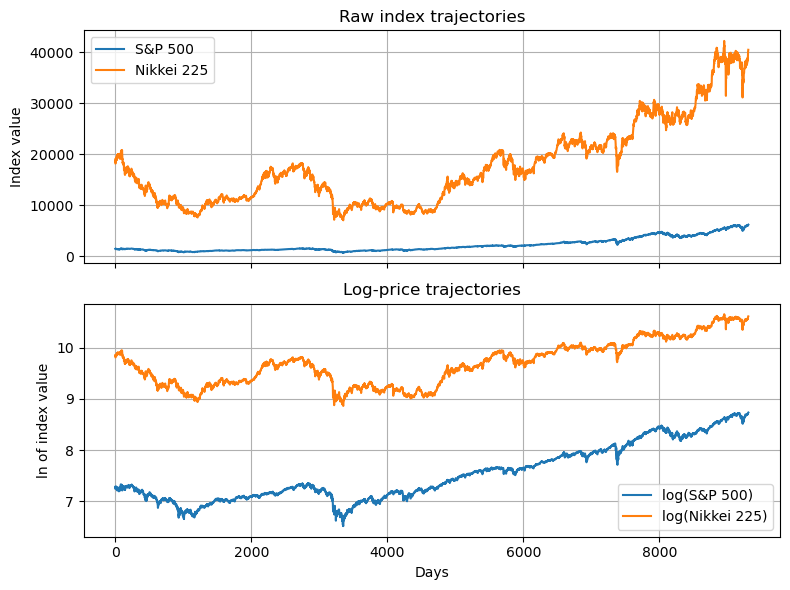

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(t_spx, l_spx, label="S&P 500")
axes[0].plot(t_n225, l_n225, label="Nikkei 225")
axes[0].set_ylabel("Index value")
axes[0].set_title("Raw index trajectories")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_spx, spx_logp, label="log(S&P 500)")
axes[1].plot(t_n225, n225_logp, label="log(Nikkei 225)")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("ln of index value")
axes[1].set_title("Log-price trajectories")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

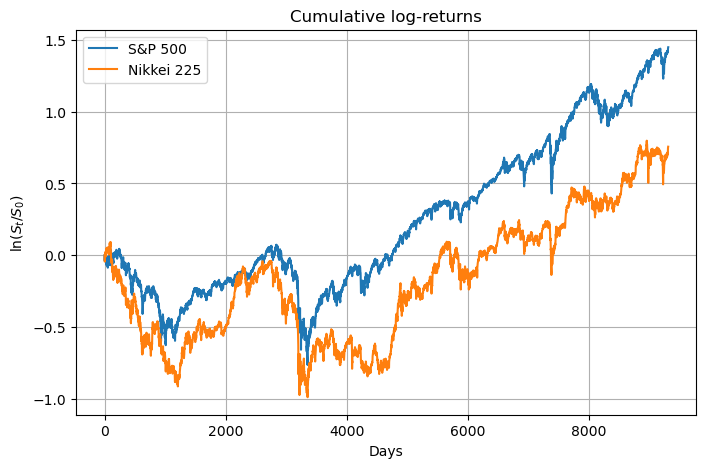

In [34]:
spx_normalized = np.log(l_spx / l_spx[0])
n225_normalized = np.log(l_n225 / l_n225[0])

plt.figure(figsize=(8, 5))
plt.plot(t_spx, spx_normalized, label="S&P 500")
plt.plot(t_n225, n225_normalized, label="Nikkei 225")
plt.xlabel("Days")
plt.ylabel(r"$\ln(S_t/S_0)$")
plt.title("Cumulative log-returns")
plt.legend()
plt.grid(True)
plt.show()

### Question 2: Estimation of the diffusion coefficient $D$

In the rest of the tutorial, we suppose that $b=0$, so that
$$
    dx_t = \sqrt{2D} \, dW_t.
$$
Hence, $x_t - x_0 \sim \mathcal{N}(0, 2Dt)$ for all $t > 0$.

The random-walk relation between displacement and time in one dimension, defining the diffusion
coefficient $D$, is the Gaussian distribution:
$$
    \mathbb{P}\left(\Delta x \mid \Delta t, D \right) = \frac{1}{\sqrt{4\pi D \, \Delta t}}e^{-\frac{\Delta x^2}{4D \, \Delta t}}
$$
so at each step of duration $\Delta t$ the mean displacement is $\mathbb{E}[\Delta x] = 0$ and its variance $\mathrm{Var}(\Delta x) = \mathbb{E}[\Delta x^2] = 2D \, \Delta t$.
Give a rough estimation of the diffusion coefficient from the data using two methods.

#### Question 2 (i): 
Give a rough estimation of the diffusion coefficient from the data (using the first and last data points).

Since $\mathbb{E}[\Delta x^2] = 2D \, \Delta t$, we estimate the expectation using the single observed squared displacement
$$
    \mathbb{E}[\Delta x^2] \approx (x_T - x_0)^2 \qquad \text{and } \qquad \Delta t \approx T-0 = T,
$$
we obtain
$$
    D \approx \frac{(x_T - x_0)^2}{2(T-0)}.
$$

In [11]:
Dspx1 = (spx_logp[-1] - spx_logp[0])**2 / (2 * (t_spx[-1] - t_spx[0]))
print(f"Estimated diffusion coefficient D for S&P 500: {Dspx1:.6f} /day")

Dn225 = (n225_logp[-1] - n225_logp[0])**2 / (2 * (t_n225[-1] - t_n225[0]))
print(f"Estimated diffusion coefficient D for Nikkei 225: {Dn225:.6f} /day")

Estimated diffusion coefficient D for S&P 500: 0.000113 /day
Estimated diffusion coefficient D for Nikkei 225: 0.000031 /day


#### Question 2 (ii): 
Give another method to estimate of the diffusion coefficient using all the data points.

What we do now is to approximate
$$
    \mathbb{E}\left[\frac{\Delta x^2}{\Delta t}\right] \approx \frac{1}{N} \sum_{i=1}^{N} \frac{\Delta x_i^2}{\Delta t_i}
$$
where $\Delta x_i := x_i - x_{i-1}$ and $\Delta t_i := t_i - t_{i-1}$, for all $i \in \{1, \dots, N\}$.

Then
$$
    D \approx \frac{1}{2N} \sum_{i=1}^{N} \frac{\Delta x_i^2}{\Delta t_i}
$$

In [35]:
Dspx2 = np.mean(np.diff(spx_logp)**2 / (2*np.diff(t_spx)))
print(f"Estimated diffusion coefficient D for S&P 500: {Dspx2:.6f} /day")

Dn225_2 = np.mean(np.diff(n225_logp)**2 / (2*np.diff(t_n225)))
print(f"Estimated diffusion coefficient D for Nikkei 225: {Dn225_2:.6f} /day")

Estimated diffusion coefficient D for S&P 500: 0.000063 /day
Estimated diffusion coefficient D for Nikkei 225: 0.000086 /day


### Question 3: Maximum-likelihood method:

Write down the probability density 
$$
    f \left(\{\Delta x_i\} \mid D, \{\Delta t_i\} \right),
$$
of the time series $(x_i)_{i=0,...,N-1}$, given $D$ and the measurement times, and deduce, using Bayes rule (uniform prior), the
posterior density of probability for the diffusion coefficient,
$$
    f \left(D \mid \{\Delta x_i, \Delta t_i\}_{i=1,...,M-1} \right).
$$

Since $dx_t = \sqrt{2D} \, dW_t$, each increment satisfies
$$
    \Delta x_i \mid D, \Delta t_i \sim \mathcal{N}(0, 2D \, \Delta t_i).
$$
Hence, its density is given by
$$
    f(\Delta x_i \mid D, \Delta t_i) = \frac{1}{\sqrt{4 \pi D \, \Delta t_i}} e^{-\frac{\Delta x_i^2}{4D \, \Delta t_i}}.
$$
Now if $x_0, \dots, x_N$ are observed, then by independence of BM increments, we have
$$
    f \left(\{\Delta x_i\} \mid D, \{\Delta t_i\} \right) = \prod_{i=1}^{N} f \left( \Delta x_i \mid D, \Delta t_i \right) = \prod_{i=1}^N \frac{1}{\sqrt{4 \pi D \, \Delta t_i}} e^{-\frac{\Delta x_i^2}{4D \, \Delta t_i}} = (4\pi D)^{-N/2} e^{-\frac{B}{2D}} \left(\prod_{i=1}^N \Delta t_i \right)^{-\frac{1}{2}} \propto D^{-N/2} e^{-\frac{B}{2D}},
$$
where
$$
    B := \frac{1}{2} \sum_{i=1}^N \frac{\Delta x_i^2}{\Delta t_i}.
$$

Now to calculate the posterior density of the diffusion coefficient $D$, we use Bayes' rule and a uniform prior on $D$, which means that the prior pdf of $D$ is constant:
$$
    f \left(D \mid \{\Delta x_i, \Delta t_i\}_{i=1,...,N} \right) = \dfrac{f \left(\{\Delta x_i\} \mid D, \{\Delta t_i\} \right) \cdot f(D)}{\int_0^{+\infty} f\left(\Delta x \mid D', \Delta t \right) \cdot f(D') \, dD'}.
$$
Hence,
$$
    f \left(D \mid \{\Delta x_i, \Delta t_i\}_{i=1,...,N} \right) \propto D^{-N/2} e^{-\frac{B}{2D}}.
$$
The normalization integral is given by
$$
    \int_0^{+\infty} D^{-N/2} e^{-\frac{B}{2D}} \, dD = \int_0^{+\infty} y^{\frac{N}{2} -2} e^{\frac{B}{2} y} \, dy = \left(\frac{B}{2}\right)^{1 - \frac{N}{2}} \Gamma\left(\frac{N}{2}-1\right),
$$
where we've done the change of variables $y = 1/D$ and used the pdf of the Gamma distribution. Therefore, the posterior density of $D$ is given by
$$
    \boxed{f\left(D \mid \{\Delta x_i,\Delta t_i\}_{i=1,\ldots,N}\right)
        =
        \frac{
            \left(\frac{B}{2}\right)^{\frac{N}{2}-1}
        }{
            \Gamma\left(\frac{N}{2}-1\right)
        }
        D^{-\frac{N}{2}}
        \exp\left(-\frac{B}{2D}\right).}
$$

### Question 4: Analytical computation:

Calculate analytically (assuming a uniform prior on $D$):

#### Question 4 (i): 
The most likely (posterior) value of the diffusion coefficient.

We can just take the natural logarithm of $f(D \mid \dots)$ and compute the derivative wrt $D$. This results in the equation
$$
    \frac{d}{dD}\left(-\frac{N}{2} \ln D - \frac{B}{2D}\right) = 0,
$$
which leads to
$$
    D^* = \frac{B}{N} = \frac{1}{2N} \sum_{i=0}^N \frac{\Delta x_i^2}{\Delta t_i}.
$$
It's easy to check that this is a maximum.

#### Question 4 (ii): 
Its average (posterior) value.

We just have to calculate the integral
$$
    \int_0^{+\infty} D f(D \mid \dots) \, dD = \left(\frac{B}{2}\right)^{1 - \frac{N}{2}} \Gamma\left(\frac{N}{2}-1\right) \int_0^{+\infty} D^{1-N/2} e^{-\frac{B}{2D}} \, dD
$$
and using the same expression we obtained before for this kind of integral, we obtain
$$
    \langle D \rangle = \mathbb{E}[D \mid \text{data}] = \left(\frac{B}{2}\right)^{1 - \frac{N}{2}} \Gamma\left(\frac{N}{2}-1\right) \left(\frac{B}{2}\right)^{2 - \frac{N}{2}} \Gamma\left(\frac{N}{2}-2\right) = \frac{B}{N - 4}.
$$

#### Question 4 (iii): 
Its (posterior) variance.

Same as before. We get
$$
    \mathrm{Var}(D) = \langle D^2 \rangle - \langle D \rangle^2 = \frac{B^2}{(N-4)(N-6)} - \frac{B^2}{(N - 4)^2} = \frac{2B^2}{(N-4)^2 (N-6)}.
$$

### Question 5: Posterior computation 

Plot the posterior distribution of $D$ obtained from the two data files. Compute, for the given datasets,
the values of the mean and of the variance of $D$, and its most likely value. Compare the results obtained
with different number $M$ of measures ($M=100$, $M=1000$ and all the data). 

**Hint:** To compute the likelihood, use Stirling's formula,

$$ n!\sim n^{n}e^{-n}\sqrt{2 \pi n} $$

S&P 500, M=100
  mode     = 1.227314e-04
  mean     = 1.278990e-04
  variance = 3.517884e-10

S&P 500, M=1000
  mode     = 7.934176e-05
  mean     = 7.966073e-05
  variance = 1.278113e-11

S&P 500, M=None
  mode     = 6.267359e-05
  mean     = 6.271272e-05
  variance = 1.228259e-12



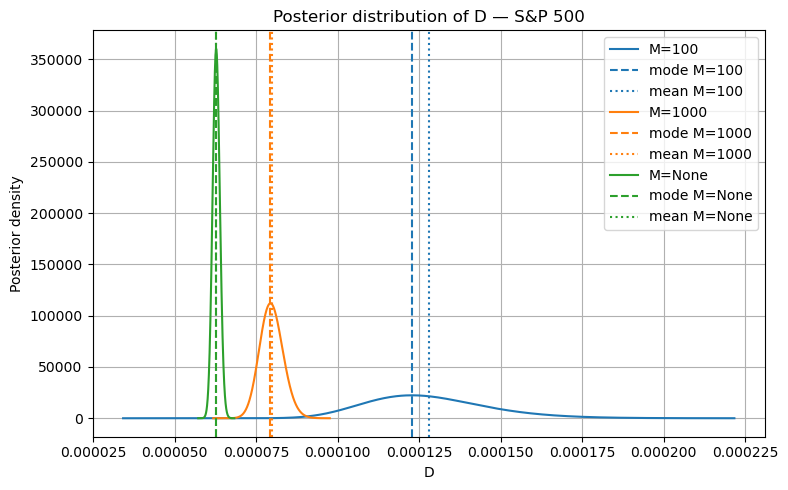

In [54]:
from scipy.special import gammaln

Ms = [100, 1000, None]

# S&P 500
plt.figure(figsize=(8, 5))

for M in Ms:
    x = spx_logp[:M]
    t = t_spx[:M]

    N = M - 1 if M is not None else len(x) - 1

    B = 0.5 * np.sum(
        np.diff(x)**2 / np.diff(t)
    )

    # Posterior statistics
    D_star = B / N
    D_mean = B / (N - 4)
    D_var = 2 * B**2 / ((N - 4)**2 * (N - 6))
    D_std = np.sqrt(D_var)

    # Plot around the region where the posterior is concentrated
    D_min = max(D_mean - 5 * D_std, 1e-12)
    D_max = D_mean + 5 * D_std
    ds = np.linspace(D_min, D_max, 500)

    log_density = (
        (N / 2 - 1) * np.log(B / 2)
        - gammaln(N / 2 - 1)
        - (N / 2) * np.log(ds)
        - B / (2 * ds)
    )

    posterior_density = np.exp(log_density)

    line, = plt.plot(
        ds,
        posterior_density,
        label=f"M={M}",
    )

    color = line.get_color()

    plt.axvline(
        D_star,
        color=color,
        linestyle="--",
        label=f"mode M={M}",
    )

    plt.axvline(
        D_mean,
        color=color,
        linestyle=":",
        label=f"mean M={M}",
    )

    print(f"S&P 500, M={M}")
    print(f"  mode     = {D_star:.6e}")
    print(f"  mean     = {D_mean:.6e}")
    print(f"  variance = {D_var:.6e}")
    print()

plt.xlabel("D")
plt.ylabel("Posterior density")
plt.title("Posterior distribution of D — S&P 500")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Nikkei 225, M=100
  mode     = 7.931770e-05
  mean     = 8.265740e-05
  variance = 1.469300e-10

Nikkei 225, M=1000
  mode     = 9.905307e-05
  mean     = 9.945127e-05
  variance = 1.992055e-11

Nikkei 225, M=None
  mode     = 8.605789e-05
  mean     = 8.611305e-05
  variance = 2.377511e-12



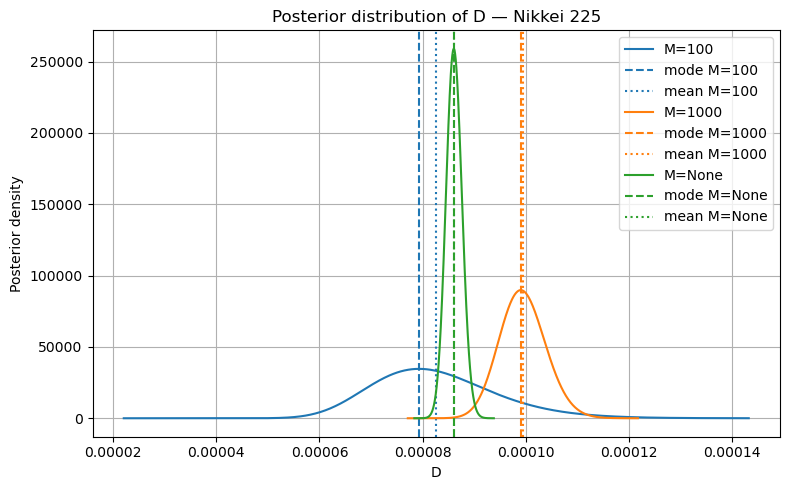

In [52]:
# Nikkei 225
plt.figure(figsize=(8, 5))

for M in Ms:
    x = n225_logp[:M]
    t = t_n225[:M]

    N = M - 1 if M is not None else len(x) - 1

    B = 0.5 * np.sum(
        np.diff(x)**2 / np.diff(t)
    )

    # Posterior statistics
    D_star = B / N
    D_mean = B / (N - 4)
    D_var = 2 * B**2 / ((N - 4)**2 * (N - 6))
    D_std = np.sqrt(D_var)

    # Plot around the region where the posterior is concentrated
    D_min = max(D_mean - 5 * D_std, 1e-12)
    D_max = D_mean + 5 * D_std
    ds = np.linspace(D_min, D_max, 500)

    log_density = (
        (N / 2 - 1) * np.log(B / 2)
        - gammaln(N / 2 - 1)
        - (N / 2) * np.log(ds)
        - B / (2 * ds)
    )

    posterior_density = np.exp(log_density)

    line, = plt.plot(
        ds,
        posterior_density,
        label=f"M={M}",
    )

    color = line.get_color()

    plt.axvline(
        D_star,
        color=color,
        linestyle="--",
        label=f"mode M={M}",
    )

    plt.axvline(
        D_mean,
        color=color,
        linestyle=":",
        label=f"mean M={M}",
    )

    print(f"Nikkei 225, M={M}")
    print(f"  mode     = {D_star:.6e}")
    print(f"  mean     = {D_mean:.6e}")
    print(f"  variance = {D_var:.6e}")
    print()

plt.xlabel("D")
plt.ylabel("Posterior density")
plt.title("Posterior distribution of D — Nikkei 225")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Question 6: Test of the bias 

In this section, we are interested in testing wether the bias in the dataset was indeed neglictible or not for the purpose of our analysis. To this end, we are going to perform an hypothesis testing of $H_0:$" the bias is 0 " versus $H_1:$ "the bias is non zero". 

#### Question 6 (i) 
Justify that, under $H_0$, the random variables $\delta x_i/\sqrt{\delta t_i}$ are i.i.d. Gaussian variables of mean 0 and variance $2D$. This implies that $\vec{X}=(\frac{\delta x_i}{\sqrt{\delta t_i}})_{i=1,...,\tilde{M}}$ is a gaussian vector with i.i.d. centered gaussian entries (with equal standard deviations).

#### Question 6 (ii) 
We will be using the following theorem which is crucial for Gaussian random variables: 

<div class="alert alert-info">

**Cochran Theorem**

Let $P_F$ be an orthogonal $\tilde{M} \times \tilde{M}$ projection matrix (symetric and $P_F^2=P_F$) on the $d-$dimensional vectorial space $F$ and $\vec{X}$ a vector with i.i.d. gaussian entries. Then, $P_F \vec{X}$ and $(I_{\tilde{M}}-P_F)\vec{X}$ are independent Gaussian vectors.

</div>

Justify that $\hat{X}_{\tilde{M}}=\sum_{i=1}^{\tilde{M}} \frac{\delta x_i}{\sqrt{\delta t_i}}$ and $\hat{s}^2_{\tilde{M}}=\frac{1}{\tilde{M}-1}\sum_{i=1}^{\tilde{M}}(\frac{\delta x_i}{\sqrt{\delta t_i}}-\hat{X}_{\tilde{M}})^2$ are independent random variables (under the hypothesis $H_0$). Compute their means.

**Hint**: $P_F$ is simple.

#### Question 6 (iii) 
$\sqrt{\tilde{M}}\hat{X}_{\tilde{M}}/\hat{s}_{\tilde{M}}$ is a random variable independent of $D$. Its law is called the [Student's t-distribution](https://en.wikipedia.org/wiki/Student%27s_t-distribution) (of $\tilde{M}-1$ degrees of liberty) available in the package `scipy.stats.t`. Compute the probability (still under $H_0$) to observe a value of $|\sqrt{\tilde{M}}\hat{X}_{\tilde{M}}/\hat{s}_{\tilde{M}}|$ as large as the one observed in the dataset. This probability is called the $p-value$, it corresponds to the probability to observe an event as "extreme" as the one observed. We reject $H_0$ if the $p-value$ is small (typically smaller than $0.05$ for 5% risk). Check wether we reject the existence of a bias or not.